## NeuralNetwork with Balanced Dataset

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
import pandas as pd

In [10]:
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

df_true = df_train[df_train['label'] == True]
df_false = df_train[df_train['label'] == False]

min_samples = min(len(df_true), len(df_false))  

df_true_bal = df_true.sample(n=min_samples, random_state=42)
df_false_bal = df_false.sample(n=min_samples, random_state=42)

df_balanced = pd.concat([df_true_bal, df_false_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print (f"Nombre d'exemples après équilibrage : {len(df_balanced)}")

X_train_text = df_balanced['func1'] + " [SEP] " + df_balanced['func2']
y_train = df_balanced['label']

X_test_text = df_test['func1'] + " [SEP] " + df_test['func2']
y_test = df_test['label']

del df_train, df_test

tfidf = TfidfVectorizer(max_features=20000, stop_words='english')

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

Nombre d'exemples après équilibrage : 900332


In [11]:
# ==========================================
# 3. GÉNÉRATEUR DE DONNÉES (L'OPTIMISATION CLÉ)
# ==========================================
class SparseDataGenerator(keras.utils.Sequence):
    """
    Génère des batchs de données pour Keras à partir de matrices sparse.
    Permet d'utiliser peu de RAM tout en entraînant sur des millions de données.
    """
    def __init__(self, x_sparse, y, batch_size=1024, shuffle=True):
        self.x_sparse = x_sparse
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(x_sparse.shape[0])
        self.on_epoch_end()

    def __len__(self):
        # Nombre de pas par époque
        return int(np.ceil(self.x_sparse.shape[0] / self.batch_size))

    def __getitem__(self, index):
        # Sélection des indices pour ce batch
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, self.x_sparse.shape[0])
        batch_indices = self.indices[start_idx:end_idx]
        
        # Conversion Sparse -> Dense uniquement pour ce petit morceau
        # C'est ici que la magie opère pour sauver la RAM
        batch_x = self.x_sparse[batch_indices].toarray()
        batch_y = self.y[batch_indices]
        
        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Création des générateurs
BATCH_SIZE = 256  # On peut monter à 256 ou 512 avec 64Go de RAM
train_gen = SparseDataGenerator(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
test_gen = SparseDataGenerator(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
# ==========================================
# 4. ARCHITECTURE DU MODÈLE
# ==========================================
print("\n--- Construction du Modèle ---")

input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    # BatchNormalization remplace StandardScaler ici.
    # Elle normalise les données par batch directement dans le GPU/CPU.
    layers.BatchNormalization(),
    
    # Bloc 1
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),  # Stabilise l'apprentissage
    layers.Dropout(0.4),
    
    # Bloc 2
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Bloc 3
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    # Sortie
    layers.Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')]
)

model.summary()


--- Construction du Modèle ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_3           │ (None, 20000)          │        80,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    10,240,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,487,937 (40.01 MB)

 Trainable params: 10,446,401 (39.85 MB)

 Non-trainable params: 41,536 (162.25 KB)

In [13]:
# ==========================================
# 5. ENTRAÎNEMENT
# ==========================================
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('checkpoints/best_balanced_model.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

print("\n--- Début de l'entraînement ---")
# Note: On passe les générateurs (train_gen) au lieu des arrays bruts
# Pour le dataset équilibré, on utilise une partie du test comme validation
from sklearn.model_selection import train_test_split

# Convertir les matrices sparse en dense pour le split (ou utiliser les indices)
indices_train = np.arange(X_train.shape[0])
train_idx, val_idx = train_test_split(indices_train, test_size=0.15, random_state=42, stratify=y_train)

# Créer les générateurs de validation
X_train_split = X_train[train_idx]
y_train_split = y_train.iloc[train_idx].values

X_val_split = X_train[val_idx]
y_val_split = y_train.iloc[val_idx].values

train_gen_split = SparseDataGenerator(X_train_split, y_train_split, batch_size=BATCH_SIZE, shuffle=True)
val_gen = SparseDataGenerator(X_val_split, y_val_split, batch_size=BATCH_SIZE, shuffle=False)

history = model.fit(
    train_gen_split,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_list,
    verbose=1
)


--- Début de l'entraînement ---
Epoch 1/20
Epoch 1/20


/opt/local/stow/conda/miniforge3/envs/cremi/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2990/2990 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9197 - auc: 0.9741 - loss: 0.6024 - precision: 0.9212 - recall: 0.9174
Epoch 1: val_auc improved from None to 0.99541, saving model to checkpoints/best_balanced_model.keras

Epoch 1: val_auc improved from None to 0.99541, saving model to checkpoints/best_balanced_model.keras
2990/2990 ━━━━━━━━━━━━━━━━━━━━ 200s 67ms/step - accuracy: 0.9460 - auc: 0.9895 - loss: 0.3928 - precision: 0.9446 - recall: 0.9475 - val_accuracy: 0.9669 - val_auc: 0.9954 - val_loss: 0.2627 - val_precision: 0.9564 - val_recall: 0.9783 - learning_rate: 0.0010
Epoch 2/20
2990/2990 ━━━━━━━━━━━━━━━━━━━━ 200s 67ms/step - accuracy: 0.9460 - auc: 0.9895 - loss: 0.3928 - precision: 0.9446 - recall: 0.9475 - val_accuracy: 0.9669 - val_auc: 0.9954 - val_loss: 0.2627 - val_precision: 0.9564 - val_recall: 0.9783 - learning_rate: 0.0010
Epoch 2/20
2990/2990 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9639 - auc: 0.9946 - loss: 0.2594 - precision: 0.9609 - recall: 0.


--- Évaluation sur le Test Set ---
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.9577 - auc: 0.9490 - loss: 0.3342 - precision: 0.8166 - recall: 0.8904
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.9577 - auc: 0.9490 - loss: 0.3342 - precision: 0.8166 - recall: 0.8904

Résultats finaux :
loss: 0.3342
compile_metrics: 0.9577
F1-Score: 0.8519

--- Génération du rapport détaillé ---

Résultats finaux :
loss: 0.3342
compile_metrics: 0.9577
F1-Score: 0.8519

--- Génération du rapport détaillé ---
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step
              precision    recall  f1-score   support

   Not Clone       0.98      0.97      0.98    358596
       Clone       0.82      0.89      0.85     56820

    accuracy                           0.96    415416
   macro avg       0.90      0.93      0.91    415416
weighted avg       0.96      0.96      0.96    415416

              precision    recall  f1-score   support

   N

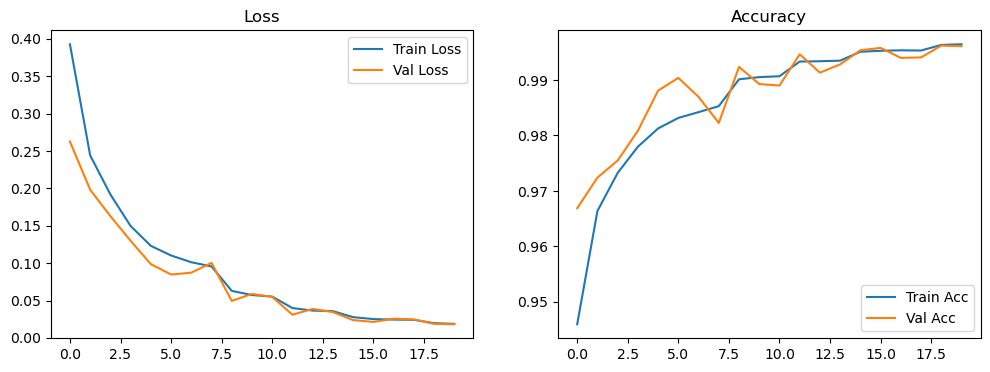

In [14]:
# ==========================================
# 6. ÉVALUATION ET VISUALISATION
# ==========================================
print("\n--- Évaluation sur le Test Set ---")
results = model.evaluate(test_gen, verbose=1)

print("\nRésultats finaux :")
for metric, value in zip(model.metrics_names, results):
    print(f"{metric}: {value:.4f}")

# Calcul du F1-Score
precision = results[2]  # index 2 car loss=0, acc=1, prec=2
recall = results[3]
f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
print(f"F1-Score: {f1:.4f}")

# Matrice de confusion
print("\n--- Génération du rapport détaillé ---")
y_pred_proba = model.predict(test_gen).flatten()
y_pred_class = (y_pred_proba > 0.5).astype(int)

# Rapport de classification
print(classification_report(y_test, y_pred_class, target_names=['Not Clone', 'Clone']))

# Afficher les courbes d'apprentissage
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()


--- Génération des courbes ROC ---
Calcul des prédictions pour Train...
2990/2990 ━━━━━━━━━━━━━━━━━━━━ 65s 22ms/step
2990/2990 ━━━━━━━━━━━━━━━━━━━━ 65s 22ms/step
Calcul des prédictions pour Validation...
Calcul des prédictions pour Validation...
528/528 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step
528/528 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step
Calcul des prédictions pour Test...
Calcul des prédictions pour Test...
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step
1623/1623 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step


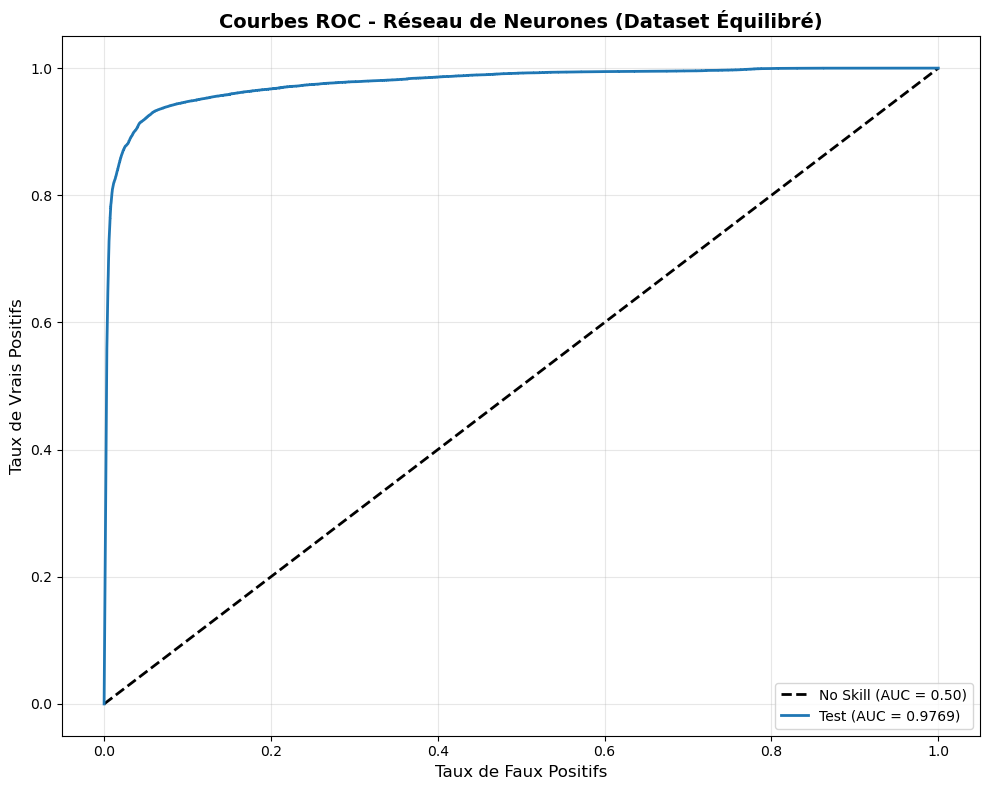


--- Résumé des AUC Scores ---
Test AUC       : 0.9769


In [17]:
# ==========================================
# 7. COURBES ROC
# ==========================================
print("\n--- Génération des courbes ROC ---")

# Prédictions de probabilités pour chaque ensemble
print("Calcul des prédictions pour Train...")
y_train_pred_proba = model.predict(train_gen_split).flatten()

print("Calcul des prédictions pour Validation...")
y_val_pred_proba = model.predict(val_gen).flatten()

print("Calcul des prédictions pour Test...")
# y_pred_proba déjà calculé dans la cellule précédente, mais on le recalcule pour la clarté
y_test_pred_proba = model.predict(test_gen).flatten()

# Calcul des courbes ROC
fpr_train, tpr_train, _ = roc_curve(y_train_split, y_train_pred_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_val, tpr_val, _ = roc_curve(y_val_split, y_val_pred_proba)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc_test = auc(fpr_test, tpr_test)

# Visualisation
plt.figure(figsize=(10, 8))

# Ligne de référence (classificateur aléatoire)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='No Skill (AUC = 0.50)')

# Courbes ROC
plt.plot(fpr_test, tpr_test, linewidth=2, label=f'Test (AUC = {roc_auc_test:.4f})')

plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbes ROC - Réseau de Neurones (Dataset Équilibré)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Résumé des AUC Scores ---")
print(f"Test AUC       : {roc_auc_test:.4f}")


--- Génération de la Matrice de Confusion ---


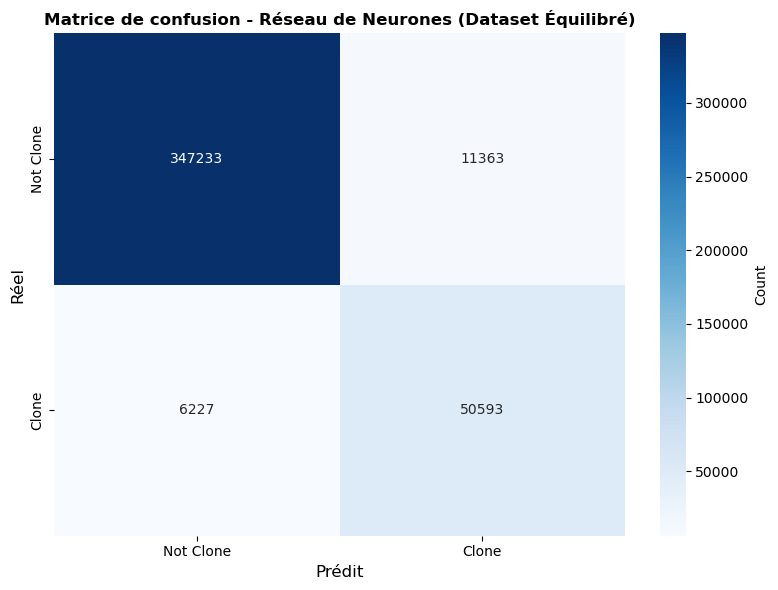


--- Détails de la Matrice de Confusion ---
True Negatives  (TN): 347,233
False Positives (FP): 11,363
False Negatives (FN): 6,227
True Positives  (TP): 50,593

--- Métriques Calculées ---
Accuracy    : 0.9577
Precision   : 0.8166
Recall (TPR): 0.8904
Specificity : 0.9683
F1-Score    : 0.8519


In [18]:
# ==========================================
# 8. MATRICE DE CONFUSION
# ==========================================
print("\n--- Génération de la Matrice de Confusion ---")

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_class)

# Visualisation avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Clone', 'Clone'], 
            yticklabels=['Not Clone', 'Clone'],
            cbar_kws={'label': 'Count'})

plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.title('Matrice de confusion - Réseau de Neurones (Dataset Équilibré)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Calcul des métriques détaillées à partir de la matrice
tn, fp, fn, tp = cm.ravel()

print("\n--- Détails de la Matrice de Confusion ---")
print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives  (TP): {tp:,}")

print("\n--- Métriques Calculées ---")
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall (TPR): {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-Score    : {f1_score:.4f}")

## Analyse des résultats avec Dataset Équilibré

Avec un dataset équilibré (même nombre d'exemples positifs et négatifs), on s'attend à:
- **Précision plus faible** : Le modèle ne peut plus simplement prédire la classe majoritaire
- **F1-Score plus élevé** : Meilleur équilibre entre précision et recall
- **Recall amélioré** : Meilleure détection des clones (moins de faux négatifs)
- **AUC similaire ou légèrement inférieure** : Compromis plus équilibré entre les classes